### 0: Downloading Programmes

In [27]:
import gurobipy as gp
from gurobipy import GRB
import pyomo.environ as pyo
from pyomo.opt import SolverFactory
import pandas as pd
from pathlib import Path
from collections import defaultdict


### 1: Dataframes

In [28]:
base = Path("output_folder")


df_resources = pd.read_csv(base / "resources.csv") # resource ID and resource type
df_constraints = pd.read_csv(base / "constraints.csv") # constraint ID and type, Name, required?, weight and cost function

df_times = pd.read_csv(base / "times.csv").sort_values("order_index") # timeslots and their timegroups (days)



# df_events = event with its duration, course, groups, role, classes and teacher)

events = pd.read_csv(base / "events.csv") 
event_groups = pd.read_csv(base / "event_eventgroup_membership.csv")
event_resources = pd.read_csv(base / "event_resources.csv")

# Events each group is part of
groups_per_event = (
    event_groups
    .groupby("event_id")["event_group_id"]
    .apply(list)
    .reset_index(name="groups")
)

# Teacher of each event
teachers_per_event = event_resources[event_resources["role"] == "Teacher"]
teachers_per_event = ( teachers_per_event[["event_id", "reference_resource_id"]]
    .groupby("event_id")["reference_resource_id"]
    .apply(list)
    .reset_index(name="teachers")
) 

#Classes in each event
classes_per_event = event_resources[event_resources["role"].astype(str).str.startswith("Class")]
classes_per_event = ( classes_per_event[["event_id", "reference_resource_id"]]
    .groupby("event_id")["reference_resource_id"]
    .apply(list)
    .reset_index(name="classes")
)

# Role of each event
role_per_event = event_resources[event_resources["resource_type_ref"] == "Room"]
role_per_event = (role_per_event[["event_id", "role"]]
    .groupby("event_id")["role"]
    .first()
    .reset_index(name="role")
)

df_events = (
    events.rename(columns={"course_ref": "course_reference"})[["event_id", "duration", "course_reference"]]
    .merge(groups_per_event, on="event_id", how="left")
    .merge(role_per_event, on="event_id", how="left")
    .merge(classes_per_event, on="event_id", how="left")
    .merge(teachers_per_event, on="event_id", how="left")
) # event with its duration, course, groups, role, classes and teacher)



resource_groups = pd.read_csv(base / "resource_group_membership.csv")

# Keep only what we need from memberships and aggregate group memberships
groups_per_resource = (
    resource_groups
    .groupby("resource_id")["resource_group_id"]
    .apply(list)
    .reset_index(name="resource_groups")
)

# Merge onto resources
df_res_with_groups = (
    df_resources[["resource_id", "resource_type_ref"]]
    .merge(groups_per_resource, on="resource_id", how="left")
)

# Replace NaN with empty list (resources that have no group membership)
df_res_with_groups["resource_groups"] = df_res_with_groups["resource_groups"].apply(
    lambda x: x if isinstance(x, list) else []
)

# Split into separate tables
df_teachers = df_res_with_groups[df_res_with_groups["resource_type_ref"] == "Teacher"].reset_index(drop=True) # teacher id, resource type and list of groups
df_classes  = df_res_with_groups[df_res_with_groups["resource_type_ref"] == "Class"].reset_index(drop=True) # class id, resource type and list of groups
df_rooms    = df_res_with_groups[df_res_with_groups["resource_type_ref"] == "Room"].reset_index(drop=True) # room id, resource type and list of groups


df_res_long = (
    df_resources[["resource_id", "resource_type_ref"]]
    .merge(resource_groups[["resource_id", "resource_group_id"]], on="resource_id", how="left")
    .rename(columns={"resource_group_id": "resource_group"})
)
df_teachers_long = df_res_long[df_res_long["resource_type_ref"] == "Teacher"] # teacher id, resource type and seperate groups
df_classes_long  = df_res_long[df_res_long["resource_type_ref"] == "Class"] # class id, resource type and seperate groups
df_rooms_long    = df_res_long[df_res_long["resource_type_ref"] == "Room"] # room id, resource type and seperate groups




df_constraint_applied = pd.read_csv(base / "constraint_applies_to.csv")
df_constraint_params = pd.read_csv(base / "constraint_params.csv")

df_constraint_params = df_constraint_params.merge(
    df_constraints[["constraint_id", "constraint_type"]],
    on="constraint_id",
    how="left"
)

df_constraint_params = df_constraint_params.merge(
    df_constraint_applied[["constraint_id", "reference"]],
    on="constraint_id",
    how="left"
)

In [29]:
#print(df_resources)
#print(df_constraints)

#print(df_times)
#print(df_events)
#print(df_rooms)
#print(df_teachers)
#print(df_classes)

#df_constraint_params



### 2a: Model setup and helpers

In [30]:

def as_list(x):
    if x is None:
        return []
    if isinstance(x, (list, tuple, set)):
        return list(x)
    return [x]




### Sets

E = df_events["event_id"].tolist() # All events
T = df_times["time_id"].tolist() # All timeslots
R = df_rooms["resource_id"].tolist() # All rooms

all_teachers = df_teachers["resource_id"].tolist()
all_classes = df_classes["resource_id"].tolist()


# event -> duration/teachers/classes (lists)
event_to_duration = dict(zip(df_events["event_id"], df_events["duration"].astype(int))) # duration of each event
event_to_teachers = dict(zip(df_events["event_id"], df_events["teachers"])) # teachers for each event
event_to_classes  = dict(zip(df_events["event_id"], df_events["classes"])) # classes for each event


# event -> room group of each event
event_to_roomgroup = dict(zip(df_events["event_id"], df_events["role"])) 

# room -> room group of each room
room_groups = {"gr_Rooms_X", "gr_Rooms_Y", "gr_Rooms_Z"}
room_to_group = (
    df_rooms_long[df_rooms_long["resource_group"].isin(room_groups)]
    .set_index("resource_id")["resource_group"]
    .to_dict()
)

# room group -> rooms in that group
group_to_rooms = defaultdict(list)
for room, grp in room_to_group.items():   # room_to_group: room -> gr_Rooms_X/Y/Z
    group_to_rooms[grp].append(room)


T_index = {t:i for i,t in enumerate(T)}

df_unavail_times = df_constraint_params[
    (df_constraint_params["constraint_type"] == "AvoidUnavailableTimesConstraint") &
    (df_constraint_params["path"] == "Times/Time")
].copy()

df_unavail_times = df_unavail_times[["reference", "value", "constraint_id"]]

# df_unavail_times has: reference (teacher), value (times teacher not available), constraint_id
unavailability = (
    df_unavail_times
    .groupby("constraint_id")
    .agg(
        teacher=("reference", "first"),
        times=("value", lambda s: sorted(set(s), key=lambda t: T_index[t]))
    )
    .to_dict(orient="index")
)

In [31]:
### Feasible Start times for events:

#T_index = {t:i for i,t in enumerate(T)}

time_to_day = dict(zip(df_times["time_id"], df_times["day_ref"]))

# Build feasible starts per event (no crossing day boundary) (implicitely covers constraints 5,9,10,11,12)
feasible_starts = {}
for e in E:
    d = int(event_to_duration[e]) # number of periods needed
    starts = []
    for ts in T: # for all possible start times
        i0 = T_index[ts]
        # must have enough periods remaining in the global list
        if i0 + d - 1 >= len(T):
            continue
        day0 = time_to_day[ts]
        block = T[i0:i0 + d]
        # enforce all times in the block are same day
        if all(time_to_day[t] == day0 for t in block):
            starts.append(ts)
    feasible_starts[e] = starts

# If event e starts at ts, then occ_times[(e, ts)] = [t1, t2, ...] is the list of all times occupied by that event
occ_times = {}
for e in E:
    d = int(event_to_duration[e])
    for ts in feasible_starts[e]:
        i0 = T_index[ts]
        occ_times[(e, ts)] = T[i0:i0 + d]


# Helper: all (e, ts) pairs that occupy a given time t
# ie for Fr_3, if event 1 is duration 1 and event 2 is duration 2, then (1, Fr_3) and (2, Fr_2) and (2, Fr_3) occupy it
occupies_at_time = {t: [] for t in T}
for e in E:
    for ts in feasible_starts[e]:
        for t in occ_times[(e, ts)]:
            occupies_at_time[t].append((e, ts))



In [32]:
# Copy so you can compare before/after if you want
feasible_starts_filtered = {}

for e in E:
    starts_ok = []
    for ts in feasible_starts[e]:
        occ = occ_times[(e, ts)]  # occupied periods if e starts at ts

        # Check teacher-specific unavailability constraints
        violates = False
        for info in unavailability.values():
            teacher = info["teacher"]
            unavail_set = set(info["times"])
            if teacher in as_list(event_to_teachers[e]):
                # if any occupied time is unavailable -> illegal
                if any(t in unavail_set for t in occ):
                    violates = True
                    break

        if not violates:
            starts_ok.append(ts)

    feasible_starts_filtered[e] = starts_ok


# Replace
feasible_starts = feasible_starts_filtered
#feasible_starts


# rebuild occ_times
occ_times = {}
for e in E:
    d = int(event_to_duration[e])
    for ts in feasible_starts[e]:
        i0 = T_index[ts]
        occ_times[(e, ts)] = T[i0:i0 + d]

# rebuild occupies_at_time
occupies_at_time = {t: [] for t in T}
for e in E:
    for ts in feasible_starts[e]:
        for t in occ_times[(e, ts)]:
            occupies_at_time[t].append((e, ts))

### 2b: Pyomo Model part 1: Sets and Decision Variables

Constraints:

Part 1: Event -> time (hard constraints):

4) AssignTimes: [gr_EventsGeneral] Every event must be assigned a time
5) Do Not Split Events: [gr_EventsGeneral] Events must inhabit consecutive periods
9) PreferredTimes: [gr_EventsDuration1] Events with duration 1 must only be allocated to times in groups gr_TimesDurationTwo
10) PreferredTimesDurationTwo: [gr_EventsDuration1] ...
11) PreferredTimesDurationThree: [gr_EventsDuration1] ...
12) PreferredTimesDurationFour: [gr_EventsDuration1] ...
13) EventSpreadingConstraint: [gr_001 - gr_150] events from each goup have a maximum and minimum specified number of events in each time group [monday, tuesday etcc...] (here max 1 per day) (event group given in course ID)
14) NoResourceClashes: No clashes for any of the resources
15) Unavailabilities_T07: [T07] selected Teacher cannot be allocated event at any of the given times, 
...
25) Unavailabilities_T17: ...

Extra: N(R_X) <= 1,  N(R_y) <= 2,  N(R_X) <= 9 in each timeslot to ensure feasability of room assignments


Part 2: Event -> time (add soft constraints):

26) JumpPeriods_Classes: [gr_classes] classes should have a minimum of 0 and maximum of 0 idle timeperiods (no timeperiod where there is no event but there is an earlier and later event on the same day) on every given time group (day) (soft) 
27) JumpPeriods_Teachers: [gr_teachers] teachers should have a minimum of 0 and maximum of 0 idle timeperiods (no timeperiod where there is no event but there is an earlier and later event on the same day) on every given time group (day) (soft)
28) MinMaxADay_Classes1: [Individual Classes] Classes should attend between 1 and 4 periods every day (soft)
29) MinMaxADay_Classes2: [Individual Classes] Classes should attend between 1 and 4 periods every day (soft)
30) MinMaxADay_Teachers1: [Individual Teachers] Teachers should teach between 1 and 4 periods every day (soft)
31) MinMaxADay_Teachers2: [Individual Teachers] Teachers should teach between 2 and 4 periods every day (soft)



Part 3: Event -> room:

1) Assign Room X: [gr_EventsGeneral(gr_Room_X)] events with role gr_Room_X must be allocated to any room.
2) Assign Room Y: [gr_EventsGeneral(gr_Room_Y)] ...
3) Assign Room Z: [gr_EventsGeneral(gr_Room_Z)] ...
6) PreferredResourcesXRooms: [gr_EventsGeneral(gr_Room_X)] events with role gr_Room_X must be allocated to a room in gr_Room_X 
7) PreferredResourcesYRooms: [gr_EventsGeneral(gr_Room_Y)] ...
8) PreferredResourcesZRooms: [gr_EventsGeneral(gr_Room_Z)] ...

### 2b: Model 1

In [ ]:
# ---- Model ----
m1 = pyo.ConcreteModel()

# ---- Sets ----
m1.E = pyo.Set(initialize=E) # Set of events
m1.T = pyo.Set(initialize=T, ordered=True) # Set of timeslots (ordered)
m1.R = pyo.Set(initialize=R) # Set of rooms

m1.Teachers = pyo.Set(initialize=all_teachers) # set of all teachers
m1.Classes = pyo.Set(initialize=all_classes) # set of all classes

# standard set up
m1.X_index = pyo.Set(
    dimen=2,
    initialize=[(e, ts) for e in E for ts in feasible_starts[e]]
)


# ---- Decision Variables ----
# x[e, ts, r] = 1 if event e starts at time ts in room r
m1.x = pyo.Var(m1.X_index, domain=pyo.Binary)

### BFCs

In [ ]:

# Standard set up

# 1) Each event scheduled exactly once (one start time)   (covers constraints 4)
def one_start_rule(m, e):
    return sum(m.x[e, ts] for ts in feasible_starts[e]) == 1
m1.OneStart = pyo.Constraint(m1.E, rule=one_start_rule)

# 2) No room conflicts: at most one event can occupy a room at a time
#def room_conflict_rule(m, r, t):
#    return sum(m.x[e, ts, r] for (e, ts) in occupies_at_time[t]) <= 1
#m.RoomConflict = pyo.Constraint(m.R, m.T, rule=room_conflict_rule)

# 3) No teacher conflicts: a teacher can teach at most one event at a time
def teacher_conflict_rule(m, teacher, t):
    terms = [
        m.x[e, ts]
        for (e, ts) in occupies_at_time.get(t, [])
        if teacher in as_list(event_to_teachers[e])
    ]
    if not terms:
        return pyo.Constraint.Skip   # or pyo.Constraint.Feasible
    return sum(terms) <= 1

m1.TeacherConflict = pyo.Constraint(all_teachers, m1.T, rule=teacher_conflict_rule)

# 4) No class conflicts: a class can attend at most one event at a time
def class_conflict_rule(m, cls, t):
    terms = [
        m.x[e, ts]
        for (e, ts) in occupies_at_time.get(t, [])
        if cls in event_to_classes[e]
    ]
    if not terms:
        return pyo.Constraint.Skip
    return sum(terms) <= 1

m1.ClassConflict = pyo.Constraint(all_classes, m1.T, rule=class_conflict_rule)



### Hard  Constraints

In [ ]:
### 3) Events that are part of the same course must be on different days (constraint 13)


# 1) Map event -> course_reference
event_to_course = dict(zip(df_events["event_id"], df_events["course_reference"]))

# 2) Build course groups (gr_C001 ... gr_C150)
courses = sorted(set(event_to_course[e] for e in E))

# 3) Days (time groups) from df_times (gr_Mo, gr_Tu, ...)
days = sorted(df_times["day_ref"].dropna().unique().tolist())

# 4) Collect relevant x vars by (course, day)
#    key -> list of all feasible (e, ts) combinations for given course and day
course_day_terms = defaultdict(list)

for (e, ts) in m1.X_index:
    c = event_to_course[e]
    d = time_to_day[ts]   # day of the start time
    course_day_terms[(c, d)].append((e, ts))

# 5) Define Pyomo sets for indexing
m1.COURSES = pyo.Set(initialize=courses)
m1.DAYS = pyo.Set(initialize=days)

# 6) Max-per-day constraint (Maximum = 1)
def event_spread_max_rule(m, c, d):
    terms = course_day_terms.get((c, d), [])
    if not terms:
        return pyo.Constraint.Skip
    return sum(m.x[e, ts] for (e, ts) in terms) <= 1 # at most one event for every course each day

m1.EventSpreadMax = pyo.Constraint(m1.COURSES, m1.DAYS, rule=event_spread_max_rule)


### Solve

In [37]:
# ---- Objective ---- (hard constraints only)
m1.obj = pyo.Objective(expr=0, sense=pyo.minimize)

In [38]:
print("vars =", m1.nvariables())
print("cons =", m1.nconstraints())


vars = 2650
cons = 1436


In [39]:
seeds = [10, 20, 30, 40, 50]

solve_times = []
objectives = []
num_vars = []
num_cons = []
solve_status = []
start_x_list = []

import time as time_module

def clear_all_var_values(model):
    for v in model.component_data_objects(pyo.Var, active=True):
        v.set_value(None, skip_validation=True)

for seed in seeds:
    clear_all_var_values(m1)

    solver = pyo.SolverFactory("gurobi")
    solver.options["TimeLimit"] = 600
    solver.options["Seed"] = seed
    solver.options["Threads"] = 1

    # Manual timing
    start_time = time_module.time()
    res = solver.solve(m1, tee=False)
    elapsed_time = time_module.time() - start_time

    solve_times.append(elapsed_time)
    objectives.append(pyo.value(m1.obj))
    num_vars.append(m1.nvariables())
    num_cons.append(m1.nconstraints())

    solve_status.append(res.solver.termination_condition)

    # Store solution
    seed_solution = {}
    for (e, ts) in m1.X_index:
        val = pyo.value(m1.x[e, ts], exception=False)
        seed_solution[(e, ts)] = 0.0 if val is None else float(val)
    start_x_list.append(seed_solution)

# Keep compatibility with later cells that expect start_x / res
start_x = start_x_list[0]
res = res

# Calculate averages
avg_time = sum(solve_times) / len(solve_times)
avg_obj = sum(objectives) / len(objectives)
avg_vars = sum(num_vars) / len(num_vars)
avg_cons = sum(num_cons) / len(num_cons)

print("=" * 50)
print("SOLVER METRICS SUMMARY - PHASE 1")
print("=" * 50)
print(f"Average Solve Time (s): {avg_time:.4f}")
print(f"Average Objective: {avg_obj:.6f}")
print(f"Average Variables: {avg_vars:.0f}")
print(f"Average Constraints: {avg_cons:.0f}")
print(f"Termination Status: {set(solve_status)}")
print("=" * 50)

print(f"\nPhase 1 produced {len(start_x_list)} solutions (one per seed)")
for i, seed_sol in enumerate(start_x_list):
    scheduled = sum(1 for v in seed_sol.values() if v > 0)
    print(f"  Seed {seeds[i]}: {scheduled} events scheduled in {solve_times[i]:.2f}s, Obj={objectives[i]:.6f}")


SOLVER METRICS SUMMARY - PHASE 1
Average Solve Time (s): 24.0201
Average Objective: 0.000000
Average Variables: 2650
Average Constraints: 1436
Termination Status: {<TerminationCondition.optimal: 'optimal'>}

Phase 1 produced 5 solutions (one per seed)
  Seed 10: 169 events scheduled in 24.99s, Obj=0.000000
  Seed 20: 169 events scheduled in 21.79s, Obj=0.000000
  Seed 30: 169 events scheduled in 22.31s, Obj=0.000000
  Seed 40: 169 events scheduled in 33.40s, Obj=0.000000
  Seed 50: 169 events scheduled in 17.61s, Obj=0.000000


### 2c: Model 2

In [ ]:
### MinMaxADay constraints:

def refs_for(constraint_id):
    return sorted(
        df_constraint_applied.loc[
            df_constraint_applied["constraint_id"].eq(constraint_id), "reference"
        ].dropna().unique().tolist()
    )

classes_1 = refs_for("MinMaxADay_Classes_1")   # min=1, max=4
classes_2 = refs_for("MinMaxADay_Classes_2")   # min=2, max=4
teachers_1 = refs_for("MinMaxADay_Teachers_1") # min=1, max=4
teachers_2 = refs_for("MinMaxADay_Teachers_2") # min=2, max=4

print("classes_1:", classes_1)
print("classes_2:", classes_2)
print("teachers_1:", teachers_1)
print("teachers_2:", teachers_2)

# Already have days stored in "days" or "m1.DAYS"





# Requires: m.X_index, event_to_classes, event_to_teachers, time_to_day

class_day_terms = defaultdict(list)    # key: (class, day)   -> list[(e,ts)] (feasible combinations)
teacher_day_terms = defaultdict(list)  # key: (teacher, day) -> list[(e,ts)]  (feasible combinations)

for (e, ts) in m1.X_index:
    d = time_to_day[ts]

    for cls in as_list(event_to_classes[e]):
        class_day_terms[(cls, d)].append((e, ts))

    for tch in as_list(event_to_teachers[e]):
        teacher_day_terms[(tch, d)].append((e, ts))

#class_day_terms, teacher_day_terms



def as_list(x):
    if x is None:
        return []
    if isinstance(x, (list, tuple, set)):
        return list(x)
    return [x]

# Build day -> timeslots once
day_to_times = defaultdict(list)
for t in m1.T:
    day_to_times[time_to_day[t]].append(t)




classes_1: ['SAA', 'SABA', 'SABB', 'SBA', 'SBB', 'SBC', 'SCA', 'SCB']
classes_2: ['SD', 'SE', 'SF', 'SG', 'SH']
teachers_1: ['T18', 'T19', 'T20', 'T21', 'T22']
teachers_2: ['T01', 'T02', 'T03', 'T04', 'T05', 'T06', 'T07', 'T08', 'T09', 'T10', 'T11', 'T12', 'T13', 'T14', 'T15', 'T16', 'T17']


In [41]:
# 1) classes_1 (min=1, max=4)

C1_MIN, C1_MAX = 1, 4
m1.C1 = pyo.Set(initialize=list(classes_1))
#m1.c1_days = pyo.Set(initialize=list(m1.DAYS))

# terms[(cls,t)] = feasible x[e,ts] making class busy at t
c1_terms = defaultdict(list) # for each [(cls,t)], all the feasible (event,timestart) combos that would make class busy at that time
c1_set = set(classes_1) # set of classes in classes_1
for t in m1.T:
    for (e, ts) in occupies_at_time.get(t, []):
        for cls in as_list(event_to_classes[e]):
            if cls in c1_set:
                c1_terms[(cls, t)].append((e, ts))

m1.c1_present = pyo.Var(m1.C1, m1.DAYS, domain=pyo.Binary) # =1 if class is busy at least once on day d
m1.c1_under   = pyo.Var(m1.C1, m1.DAYS, domain=pyo.NonNegativeReals) # classes_1 shortage of events below minimum (1)
m1.c1_over    = pyo.Var(m1.C1, m1.DAYS, domain=pyo.NonNegativeReals) # classes_1 excess of events above maximum (1)

# Iterates over each timeslot in a day and for each t, it adds events that occupy that t (from c1_terms[(cls, t)] (ie. calculates number of busy times in the day)
def c1_busy_rule(m, cls, d):
    return sum(m.x[e, ts] for t in day_to_times[d] for (e, ts) in c1_terms.get((cls, t), []))
m1.c1_busy = pyo.Expression(m1.C1, m1.DAYS, rule=c1_busy_rule)


# Together these force c1_present = 0 if c1_busy = 0 and c1_present = 1 if c1_busy >= 1
def c1_present_upper(m, cls, d):
    return m.c1_busy[cls, d] <= len(day_to_times[d]) * m.c1_present[cls, d]
m1.C1PresentUpper = pyo.Constraint(m1.C1, m1.DAYS, rule=c1_present_upper)

def c1_present_lower(m, cls, d):
    return m.c1_busy[cls, d] >= m.c1_present[cls, d]
m1.C1PresentLower = pyo.Constraint(m1.C1, m1.DAYS, rule=c1_present_lower)


# Measures shortage below the minimum, class not present on a day -> RHS is -c1_busy -> busy forced to 0. Presnt = 1 and busy < C1-min -> RHS is +ve and under must cover gap
def c1_under_def(m, cls, d):
    return m.c1_under[cls, d] >= C1_MIN * m.c1_present[cls, d] - m.c1_busy[cls, d]
m1.C1UnderDef = pyo.Constraint(m1.C1, m1.DAYS, rule=c1_under_def)

# Measures exess above maximum. busy > C1_Max -> RHS +ve so over must cover exess etc...
def c1_over_def(m, cls, d):
    return m.c1_over[cls, d] >= m.c1_busy[cls, d] - C1_MAX
m1.C1OverDef = pyo.Constraint(m1.C1, m1.DAYS, rule=c1_over_def)

m1.PenaltyClass1Busy = pyo.Expression(
    expr=sum((m1.c1_under[c,d] + m1.c1_over[c,d])**2 for c in m1.C1 for d in m1.DAYS) # squares total deviation for each class-day
)




# 2) classes_2 (min=2, max=4)
C2_MIN, C2_MAX = 2, 4
m1.C2 = pyo.Set(initialize=list(classes_2))
#m1.c2_days = pyo.Set(initialize=list(m1.DAYS))

c2_terms = defaultdict(list)
c2_set = set(classes_2)
for t in m1.T:
    for (e, ts) in occupies_at_time.get(t, []):
        for cls in as_list(event_to_classes[e]):
            if cls in c2_set:
                c2_terms[(cls, t)].append((e, ts))

m1.c2_present = pyo.Var(m1.C2, m1.DAYS, domain=pyo.Binary)
m1.c2_under   = pyo.Var(m1.C2, m1.DAYS, domain=pyo.NonNegativeReals)
m1.c2_over    = pyo.Var(m1.C2, m1.DAYS, domain=pyo.NonNegativeReals)

def c2_busy_rule(m, cls, d):
    return sum(m.x[e, ts] for t in day_to_times[d] for (e, ts) in c2_terms.get((cls, t), []))
m1.c2_busy = pyo.Expression(m1.C2, m1.DAYS, rule=c2_busy_rule)

def c2_present_upper_rule(m, cls, d):
    return m.c2_busy[cls, d] <= len(day_to_times[d]) * m.c2_present[cls, d]
m1.C2PresentUpper = pyo.Constraint(m1.C2, m1.DAYS, rule=c2_present_upper_rule)

def c2_present_lower_rule(m, cls, d):
    return m.c2_busy[cls, d] >= m.c2_present[cls, d]
m1.C2PresentLower = pyo.Constraint(m1.C2, m1.DAYS, rule=c2_present_lower_rule)

def c2_under_def_rule(m, cls, d):
    return m.c2_under[cls, d] >= C2_MIN * m.c2_present[cls, d] - m.c2_busy[cls, d]
m1.C2UnderDef = pyo.Constraint(m1.C2, m1.DAYS, rule=c2_under_def_rule)

def c2_over_def_rule(m, cls, d):
    return m.c2_over[cls, d] >= m.c2_busy[cls, d] - C2_MAX
m1.C2OverDef = pyo.Constraint(m1.C2, m1.DAYS, rule=c2_over_def_rule)

m1.PenaltyClass2Busy = pyo.Expression(
    expr=sum((m1.c2_under[c, d] + m1.c2_over[c, d])**2 for c in m1.C2 for d in m1.DAYS)
)


# 3) teachers_1 (min=1, max=4)
T1_MIN, T1_MAX = 1, 4
m1.T1 = pyo.Set(initialize=list(teachers_1))
#m1.t1_days = pyo.Set(initialize=list(m1.DAYS))

t1_terms = defaultdict(list)
t1_set = set(teachers_1)
for t in m1.T:
    for (e, ts) in occupies_at_time.get(t, []):
        for tch in as_list(event_to_teachers[e]):
            if tch in t1_set:
                t1_terms[(tch, t)].append((e, ts))

m1.t1_present = pyo.Var(m1.T1, m1.DAYS, domain=pyo.Binary)
m1.t1_under   = pyo.Var(m1.T1, m1.DAYS, domain=pyo.NonNegativeReals)
m1.t1_over    = pyo.Var(m1.T1, m1.DAYS, domain=pyo.NonNegativeReals)

def t1_busy_rule(m, tch, d):
    return sum(m.x[e, ts] for t in day_to_times[d] for (e, ts) in t1_terms.get((tch, t), []))
m1.t1_busy = pyo.Expression(m1.T1, m1.DAYS, rule=t1_busy_rule)

def t1_present_upper_rule(m, tch, d):
    return m.t1_busy[tch, d] <= len(day_to_times[d]) * m.t1_present[tch, d]
m1.T1PresentUpper = pyo.Constraint(m1.T1, m1.DAYS, rule=t1_present_upper_rule)

def t1_present_lower_rule(m, tch, d):
    return m.t1_busy[tch, d] >= m.t1_present[tch, d]
m1.T1PresentLower = pyo.Constraint(m1.T1, m1.DAYS, rule=t1_present_lower_rule)

def t1_under_def_rule(m, tch, d):
    return m.t1_under[tch, d] >= T1_MIN * m.t1_present[tch, d] - m.t1_busy[tch, d]
m1.T1UnderDef = pyo.Constraint(m1.T1, m1.DAYS, rule=t1_under_def_rule)

def t1_over_def_rule(m, tch, d):
    return m.t1_over[tch, d] >= m.t1_busy[tch, d] - T1_MAX
m1.T1OverDef = pyo.Constraint(m1.T1, m1.DAYS, rule=t1_over_def_rule)

m1.PenaltyTeacher1Busy = pyo.Expression(
    expr=sum((m1.t1_under[t, d] + m1.t1_over[t, d])**2 for t in m1.T1 for d in m1.DAYS)
)


# 4) teachers_2 (min=2, max=4)
T2_MIN, T2_MAX = 2, 4
m1.T2 = pyo.Set(initialize=list(teachers_2))
#m1.t2_days = pyo.Set(initialize=list(m1.DAYS))

t2_terms = defaultdict(list)
t2_set = set(teachers_2)
for t in m1.T:
    for (e, ts) in occupies_at_time.get(t, []):
        for tch in as_list(event_to_teachers[e]):
            if tch in t2_set:
                t2_terms[(tch, t)].append((e, ts))

m1.t2_present = pyo.Var(m1.T2, m1.DAYS, domain=pyo.Binary)
m1.t2_under   = pyo.Var(m1.T2, m1.DAYS, domain=pyo.NonNegativeReals)
m1.t2_over    = pyo.Var(m1.T2, m1.DAYS, domain=pyo.NonNegativeReals)

def t2_busy_rule(m, tch, d):
    return sum(m.x[e, ts] for t in day_to_times[d] for (e, ts) in t2_terms.get((tch, t), []))
m1.t2_busy = pyo.Expression(m1.T2, m1.DAYS, rule=t2_busy_rule)

def t2_present_upper_rule(m, tch, d):
    return m.t2_busy[tch, d] <= len(day_to_times[d]) * m.t2_present[tch, d]
m1.T2PresentUpper = pyo.Constraint(m1.T2, m1.DAYS, rule=t2_present_upper_rule)

def t2_present_lower_rule(m, tch, d):
    return m.t2_busy[tch, d] >= m.t2_present[tch, d]
m1.T2PresentLower = pyo.Constraint(m1.T2, m1.DAYS, rule=t2_present_lower_rule)

def t2_under_def_rule(m, tch, d):
    return m.t2_under[tch, d] >= T2_MIN * m.t2_present[tch, d] - m.t2_busy[tch, d]
m1.T2UnderDef = pyo.Constraint(m1.T2, m1.DAYS, rule=t2_under_def_rule)

def t2_over_def_rule(m, tch, d):
    return m.t2_over[tch, d] >= m.t2_busy[tch, d] - T2_MAX
m1.T2OverDef = pyo.Constraint(m1.T2, m1.DAYS, rule=t2_over_def_rule)

m1.PenaltyTeacher2Busy = pyo.Expression(
    expr=sum((m1.t2_under[t, d] + m1.t2_over[t, d])**2 for t in m1.T2 for d in m1.DAYS)
)




In [42]:

pos_in_day = {}
for d, times in day_to_times.items():
    for i, t in enumerate(times, start=1):
        pos_in_day[(d, t)] = i

In [ ]:

# JumpPeriods_Classes (min=0, max=0), soft, SumSquares, weight=1

m1.GC = pyo.Set(initialize=list(all_classes))  # set of all classes


# q_class[c,t] = 1 if class c is busy at time t
class_terms = defaultdict(list)  # for each (class,t) -> gives list of (event, starttime) combos where class is busy at time t
for t in T:
    for (e, ts) in occupies_at_time.get(t, []):
        for c in as_list(event_to_classes[e]):
            if c in m1.GC:
                class_terms[(c, t)].append((e, ts))




m1.q_class = pyo.Var(m1.GC, m1.T, domain=pyo.Binary) # = 1 if classc has some selected event occupying time t

def class_busy_def_rule(m, c, t):
    return m.q_class[c, t] == sum(m.x[e, ts] for (e, ts) in class_terms.get((c, t), []))
m1.ClassBusyDef = pyo.Constraint(m1.GC, m1.T, rule=class_busy_def_rule)

m1.y_class = pyo.Var(m1.GC, m1.DAYS, domain=pyo.Binary)  # class busy at least once in day
m1.first_class = pyo.Var(m1.GC, m1.DAYS, domain=pyo.NonNegativeIntegers) # position of first busy time on that day
m1.last_class  = pyo.Var(m1.GC, m1.DAYS, domain=pyo.NonNegativeIntegers) # position of last busy time on that day
m1.idle_class  = pyo.Var(m1.GC, m1.DAYS, domain=pyo.NonNegativeIntegers) # number of idle periods that day


# Total busy timeslots for class c on day d
def class_busy_count_rule(m, c, d):
    return sum(m.q_class[c, t] for t in day_to_times[d])
m1.class_busy_count = pyo.Expression(m1.GC, m1.DAYS, rule=class_busy_count_rule)



# if y_class = 0 -> frist constraint gives busy_count <= 0 so busy_count=0 
# if busy_count >= 0 -> second costraint forcces y = 1
# hence y = 1 if class is busy at least once that day
def class_present_up_rule(m, c, d):
    nd = len(day_to_times[d])
    return m.class_busy_count[c, d] <= nd * m.y_class[c, d]
m1.ClassPresentUp = pyo.Constraint(m1.GC, m1.DAYS, rule=class_present_up_rule)
 
def class_present_lo_rule(m, c, d):
    return m.class_busy_count[c, d] >= m.y_class[c, d]
m1.ClassPresentLo = pyo.Constraint(m1.GC, m1.DAYS, rule=class_present_lo_rule)





# these 3 onstraints force first=1, last=0 when no busy in day (y=0)  -> Idle formula becomes: idle = last - first + 1 - busy_count = 0 -1 +1 -0 = 0
# if y = 1 -> first can be between 1 and nd, last can be between 0 and nd
def class_first_fix_rule(m, c, d):
    nd = len(day_to_times[d])
    return m.first_class[c, d] <= 1 + (nd - 1) * m.y_class[c, d]
m1.ClassFirstFix = pyo.Constraint(m1.GC, m1.DAYS, rule=class_first_fix_rule)

def class_first_lb_rule(m, c, d):
    return m.first_class[c, d] >= 1
m1.ClassFirstLB = pyo.Constraint(m1.GC, m1.DAYS, rule=class_first_lb_rule)

def class_last_fix_rule(m, c, d):
    nd = len(day_to_times[d])
    return m.last_class[c, d] <= nd * m.y_class[c, d]
m1.ClassLastFix = pyo.Constraint(m1.GC, m1.DAYS, rule=class_last_fix_rule)

# Envelope first/last busy positions
#sets first and last busy positions of day
# if busy at t (q=1): force first <= p and last >= p;
# if not busy (q=0): constraints loosen.
m1.ClassFirstEnv = pyo.ConstraintList()
m1.ClassLastEnv = pyo.ConstraintList()
for c in m1.GC:
    for d in m1.DAYS:
        nd = len(day_to_times[d])
        for t in day_to_times[d]:
            p = pos_in_day[(d, t)]
            m1.ClassFirstEnv.add(m1.first_class[c, d] <= p + nd * (1 - m1.q_class[c, t]))
            m1.ClassLastEnv.add(m1.last_class[c, d] >= p * m1.q_class[c, t])

# calculates the idle periods in each day for each class
def class_idle_def_rule(m, c, d):
    return m.idle_class[c, d] == m.last_class[c, d] - m.first_class[c, d] + 1 - m.class_busy_count[c, d]
m1.ClassIdleDef = pyo.Constraint(m1.GC, m1.DAYS, rule=class_idle_def_rule)

# min=max=0 => deviation = idle count
m1.PenaltyJumpClasses = pyo.Expression(
    expr=sum(m1.idle_class[c, d]**2 for c in m1.GC for d in m1.DAYS)
)

In [ ]:


# JumpPeriods_Teachers (min=0, max=0), soft, SumSquares, weight=1

m1.GT = pyo.Set(initialize=list(all_teachers))

teacher_terms = defaultdict(list)    # for each teacher,time (g,t) -> gives list of (event, starttime) combos where class is busy at time t
for t in T:
    for (e, ts) in occupies_at_time.get(t, []):
        for g in as_list(event_to_teachers[e]):
            if g in m1.GT:
                teacher_terms[(g, t)].append((e, ts))


m1.q_teacher = pyo.Var(m1.GT, m1.T, domain=pyo.Binary) # = 1 if teacher has some selected event occupying time t


def teacher_busy_def_rule(m, g, t):
    return m.q_teacher[g, t] == sum(m.x[e, ts] for (e, ts) in teacher_terms.get((g, t), []))
m1.TeacherBusyDef = pyo.Constraint(m1.GT, m1.T, rule=teacher_busy_def_rule)

m1.y_teacher = pyo.Var(m1.GT, m1.DAYS, domain=pyo.Binary) # teacher busy at least once in day
m1.first_teacher = pyo.Var(m1.GT, m1.DAYS, domain=pyo.NonNegativeIntegers) #first busy period in day
m1.last_teacher  = pyo.Var(m1.GT, m1.DAYS, domain=pyo.NonNegativeIntegers) # last busy period in day
m1.idle_teacher  = pyo.Var(m1.GT, m1.DAYS, domain=pyo.NonNegativeIntegers) # numer of idle periods in day


# Total busy timeslots for class c on day d
def teacher_busy_count_rule(m, g, d):
    return sum(m.q_teacher[g, t] for t in day_to_times[d])
m1.teacher_busy_count = pyo.Expression(m1.GT, m1.DAYS, rule=teacher_busy_count_rule)




# if y_teacher = 0 -> first constraint gives busy_count <= 0 so busy_count=0 
# if busy_count >= 0 -> second costraint forcces y = 1
# hence y = 1 if teacher is busy at least once that day
def teacher_present_up_rule(m, g, d):
    nd = len(day_to_times[d])
    return m.teacher_busy_count[g, d] <= nd * m.y_teacher[g, d]
m1.TeacherPresentUp = pyo.Constraint(m1.GT, m1.DAYS, rule=teacher_present_up_rule)

def teacher_present_lo_rule(m, g, d):
    return m.teacher_busy_count[g, d] >= m.y_teacher[g, d]
m1.TeacherPresentLo = pyo.Constraint(m1.GT, m1.DAYS, rule=teacher_present_lo_rule)



# these 3 onstraints force first=1, last=0 when no busy in day (y=0)  -> Idle formula becomes: idle = last - first + 1 - busy_count = 0 -1 +1 -0 = 0
# if y = 1 -> first can be between 1 and nd, last can be between 0 and nd
def teacher_first_fix_rule(m, g, d):
    nd = len(day_to_times[d])
    return m.first_teacher[g, d] <= 1 + (nd - 1) * m.y_teacher[g, d]
m1.TeacherFirstFix = pyo.Constraint(m1.GT, m1.DAYS, rule=teacher_first_fix_rule)

def teacher_first_lb_rule(m, g, d):
    return m.first_teacher[g, d] >= 1
m1.TeacherFirstLB = pyo.Constraint(m1.GT, m1.DAYS, rule=teacher_first_lb_rule)

def teacher_last_fix_rule(m, g, d):
    nd = len(day_to_times[d])
    return m.last_teacher[g, d] <= nd * m.y_teacher[g, d]
m1.TeacherLastFix = pyo.Constraint(m1.GT, m1.DAYS, rule=teacher_last_fix_rule)


# Envelope first/last busy positions
#sets first and last busy positions of day
# if busy at t (q=1): force first <= p and last >= p;
# if not busy (q=0): constraints loosen.
#This pins first/last around busy positions.
m1.TeacherFirstEnv = pyo.ConstraintList()
m1.TeacherLastEnv = pyo.ConstraintList()
for g in m1.GT:
    for d in m1.DAYS:
        nd = len(day_to_times[d])
        for t in day_to_times[d]:
            p = pos_in_day[(d, t)]
            m1.TeacherFirstEnv.add(m1.first_teacher[g, d] <= p + nd * (1 - m1.q_teacher[g, t]))
            m1.TeacherLastEnv.add(m1.last_teacher[g, d] >= p * m1.q_teacher[g, t])


# calculates the idle periods in each day for each class
def teacher_idle_def_rule(m, g, d):
    return m.idle_teacher[g, d] == m.last_teacher[g, d] - m.first_teacher[g, d] + 1 - m.teacher_busy_count[g, d]
m1.TeacherIdleDef = pyo.Constraint(m1.GT, m1.DAYS, rule=teacher_idle_def_rule)


# min=max=0 => deviation = idle count
m1.PenaltyJumpTeachers = pyo.Expression(
    expr=sum(m1.idle_teacher[g, d]**2 for g in m1.GT for d in m1.DAYS)
)


### Solve

In [ ]:
# ---- Objective ---- (with soft constraints)

if hasattr(m1, "obj"):
    m1.del_component(m1.obj)


# weights 
w_c1 = 1.0
w_c2 = 1.0
w_t1 = 1.0
w_t2 = 1.0
w_jc = 1.0
w_jt = 1.0

penalty_total = (
    w_c1 * m1.PenaltyClass1Busy
    + w_c2 * m1.PenaltyClass2Busy
    + w_t1 * m1.PenaltyTeacher1Busy
    + w_t2 * m1.PenaltyTeacher2Busy
    + w_jc * m1.PenaltyJumpClasses
    + w_jt * m1.PenaltyJumpTeachers
)

m1.obj = pyo.Objective(expr=penalty_total, sense=pyo.minimize)


In [46]:
print("m2 vars =", m1.nvariables())
print("m2 cons =", m1.nconstraints())
print("m2 X_index size =", len(list(m1.X_index)))


m2 vars = 4575
m2 cons = 5286
m2 X_index size = 2650



PHASE 2 - Warm Start from Seed 10


containing a solution
Assigned x warm-start values: 2650
Solver status: aborted
Termination: maxTimeLimit
Warm start accepted: True
MIP start log:
   User MIP start produced solution with objective 15 (0.03s)
   Loaded user MIP start with objective 15
Objective: 5.000000
Solve time: 600.79s
Heuristic updates found: 7
Variables: 4575
Constraints: 5286
Nonzeros: 54411

PHASE 2 - Warm Start from Seed 20
containing a solution
Assigned x warm-start values: 2650
Solver status: aborted
Termination: maxTimeLimit
Warm start accepted: True
MIP start log:
   User MIP start produced solution with objective 19 (0.03s)
   Loaded user MIP start with objective 19
Objective: 2.000000
Solve time: 600.95s
Heuristic updates found: 14
Variables: 4575
Constraints: 5286
Nonzeros: 54411

PHASE 2 - Warm Start from Seed 30
containing a solution
Assigned x warm-start values: 2650
Solver status: aborted
Termination: maxTimeLimit
Warm start accepted: True
MIP start log:
   User MIP start produced solution with obj

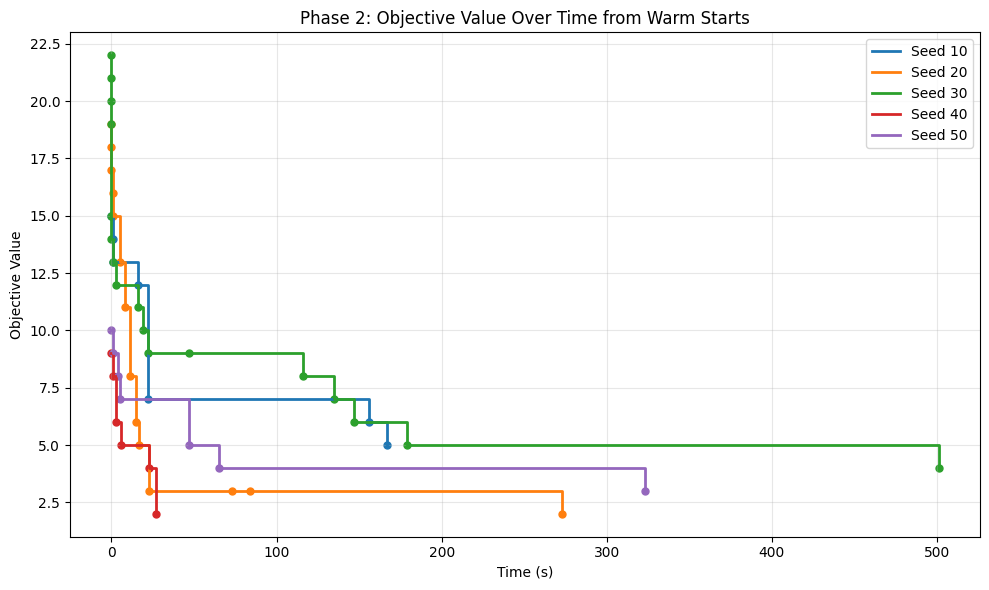

In [ ]:
import os
import re
import time as time_module
import numpy as np
import matplotlib.pyplot as plt
import pyomo.environ as pyo

TIME_LIMIT = 600
LOG_DIR = "gurobi_phase2_logs"
SENSE = "min"
os.makedirs(LOG_DIR, exist_ok=True)


def clear_all_var_values(model):
    for v in model.component_data_objects(pyo.Var, active=True):
        v.set_value(None, skip_validation=True)


def load_x_warm_start(model, seed_solution, tol=0.5):
    # Start from a clean model state so no stale values are exported
    clear_all_var_values(model)

    assigned = 0
    for idx in model.X_index:
        val = seed_solution.get(idx, 0.0)
        start_val = 1 if val > tol else 0
        model.x[idx].set_value(start_val, skip_validation=True)
        assigned += 1

    return assigned


def parse_model_stats(logfile):
    rows = cols = nnz = None
    pat = re.compile(
        r"Optimize a model with\s+(\d+)\s+rows,\s+(\d+)\s+columns and\s+(\d+)\s+nonzeros"
    )
    with open(logfile, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            m = pat.search(line)
            if m:
                rows = int(m.group(1))
                cols = int(m.group(2))
                nnz = int(m.group(3))
                break
    return rows, cols, nnz


def parse_heuristic_trajectory(logfile):
    times = []
    objs = []

    elapsed_pat = re.compile(
        r"Elapsed time for NoRel heuristic:\s*([0-9]+(?:\.[0-9]+)?)s"
    )
    found_pat = re.compile(
        r"Found heuristic solution:\s*objective\s*([+-]?\d+(?:\.\d+)?(?:[eE][+-]?\d+)?)"
    )
    mip_start_pat = re.compile(
        r"Loaded user MIP start with objective\s*([+-]?\d+(?:\.\d+)?(?:[eE][+-]?\d+)?)"
    )

    current_time = None

    with open(logfile, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()

            m = elapsed_pat.search(s)
            if m:
                current_time = float(m.group(1))
                continue

            m = mip_start_pat.search(s)
            if m:
                times.append(0.0)
                objs.append(float(m.group(1)))
                continue

            m = found_pat.search(s)
            if m:
                times.append(current_time)
                objs.append(float(m.group(1)))
                continue

            if s.startswith("H") or s.startswith("*"):
                toks = s.split()
                if toks[0] == "H" and len(toks) >= 8:
                    objs.append(float(toks[3]))
                    times.append(float(toks[-1].rstrip("s")))
                elif toks[0] == "*" and len(toks) >= 9:
                    objs.append(float(toks[4]))
                    times.append(float(toks[-1].rstrip("s")))

    return times, objs



def parse_first_feasible_time(logfile):
    elapsed_pat = re.compile(
        r"Elapsed time for NoRel heuristic:\s*([0-9]+(?:\.[0-9]+)?)s"
    )
    found_pat = re.compile(
        r"Found heuristic solution:\s*objective\s*([+-]?\d+(?:\.\d+)?(?:[eE][+-]?\d+)?)"
    )
    mip_start_pat = re.compile(
        r"Loaded user MIP start with objective\s*([+-]?\d+(?:\.\d+)?(?:[eE][+-]?\d+)?)"
    )

    current_time = None

    with open(logfile, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()

            m = elapsed_pat.search(s)
            if m:
                current_time = float(m.group(1))
                continue

            m = mip_start_pat.search(s)
            if m:
                return 0.0, float(m.group(1)), "warm_start"

            m = found_pat.search(s)
            if m:
                return current_time, float(m.group(1)), "heuristic_log"

    return None, None, None


def parse_mip_start_status(logfile):
    accepted = False
    messages = []

    with open(logfile, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if "User MIP start" in s or "Loaded user MIP start" in s:
                messages.append(s)
            if "Loaded user MIP start" in s or "User MIP start produced solution" in s:
                accepted = True

    return accepted, messages


phase2_results = []
trajectories = []

for i, seed_solution in enumerate(start_x_list):
    seed = seeds[i]

    print(f"\n{'='*60}")
    print(f"PHASE 2 - Warm Start from Seed {seed}")
    print(f"{'='*60}")

    assigned = load_x_warm_start(m1, seed_solution)

    logfile = os.path.join(LOG_DIR, f"phase2_seed_{seed}.log")
    if os.path.exists(logfile):
        os.remove(logfile)

    solver2 = pyo.SolverFactory("gurobi")
    solver2.options["TimeLimit"] = TIME_LIMIT
    solver2.options["Seed"] = seed
    solver2.options["MIPFocus"] = 1
    solver2.options["Heuristics"] = 0.5
    solver2.options["NoRelHeurTime"] = TIME_LIMIT
    solver2.options["DisplayInterval"] = 1
    solver2.options["LogFile"] = logfile
    solver2.options["Threads"] = 1

    start_time = time_module.time()
    res2 = solver2.solve(m1, tee=False, warmstart=True, load_solutions=False)
    elapsed_time = time_module.time() - start_time

    solver_status = str(res2.solver.status)
    termination = str(res2.solver.termination_condition)

    has_solution = len(res2.solution) > 0
    if has_solution:
        m1.solutions.load_from(res2)

    try:
        obj2 = pyo.value(m1.obj) if has_solution else float("nan")
    except:
        obj2 = float("nan")
        has_solution = False

    chosen_start = {}
    if has_solution:
        for e in m1.E:
            picked = [
                ts for ts in feasible_starts[e]
                if pyo.value(m1.x[e, ts], exception=False) is not None
                and pyo.value(m1.x[e, ts]) > 0.5
            ]
            if len(picked) != 1:
                raise ValueError(f"Event {e}: expected exactly 1 chosen start, got {picked}")
            chosen_start[e] = picked[0]


    num_vars = m1.nvariables()
    num_cons = m1.nconstraints()
    rows_log, cols_log, nnz_log = parse_model_stats(logfile)
    tvals, ovals = parse_heuristic_trajectory(logfile)
    first_feas_time, first_feas_obj, first_feas_source = parse_first_feasible_time(logfile)
    mip_start_accepted, mip_start_messages = parse_mip_start_status(logfile)

    if has_solution:
        if not tvals:
            tvals.append(elapsed_time)
            ovals.append(obj2)
        elif abs(ovals[-1] - obj2) > 1e-9 and elapsed_time > (tvals[-1] if tvals[-1] is not None else -1):
            tvals.append(elapsed_time)
            ovals.append(obj2)

    phase2_results.append({
        "seed": seed,
        "solver_status": solver_status,
        "termination": termination,
        "objective": obj2,
        "solve_time": elapsed_time,
        "num_vars": num_vars if num_vars is not None else cols_log,
        "num_cons": num_cons if num_cons is not None else rows_log,
        "num_nonzeros": nnz_log,
        "has_solution": has_solution,
        "assigned_start_values": assigned,
        "chosen_start": chosen_start,
        "mip_start_accepted": mip_start_accepted,
        "mip_start_messages": mip_start_messages,
        "n_heuristic_updates": len(tvals),
        "first_feasible_time": first_feas_time,
        "first_feasible_objective": first_feas_obj,
        "first_feasible_source": first_feas_source,
        "logfile": logfile,
    })


    trajectories.append({
        "seed": seed,
        "times": tvals,
        "objectives": ovals,
    })

    print(f"Assigned x warm-start values: {assigned}")
    print(f"Solver status: {solver_status}")
    print(f"Termination: {termination}")
    print(f"Warm start accepted: {mip_start_accepted}")
    if mip_start_messages:
        print("MIP start log:")
        for msg in mip_start_messages:
            print("  ", msg)
    print(f"Objective: {obj2:.6f}" if has_solution else "Objective: No solution loaded")
    print(f"Solve time: {elapsed_time:.2f}s")
    print(f"Heuristic updates found: {len(tvals)}")
    print(f"Variables: {num_vars}")
    print(f"Constraints: {num_cons}")
    print(f"Nonzeros: {nnz_log}")



# SUMMARY

valid_objs = [r["objective"] for r in phase2_results if not np.isnan(r["objective"])]
avg_time = np.mean([r["solve_time"] for r in phase2_results])

print(f"\n{'='*60}")
print("PHASE 2 SUMMARY")
print(f"{'='*60}")
for r in phase2_results:
    obj_str = f"{r['objective']:.6f}" if not np.isnan(r["objective"]) else "No solution"
    first_time_str = (
        f"{r['first_feasible_time']:.2f}s"
        if r["first_feasible_time"] is not None
        else "Not found"
    )
    first_obj_str = (
        f"{r['first_feasible_objective']:.6f}"
        if r["first_feasible_objective"] is not None
        else "Not found"
    )
    print(
        f"Seed {r['seed']}: "
        f"Status={r['solver_status']}, "
        f"Termination={r['termination']}, "
        f"Obj={obj_str}, "
        f"Time={r['solve_time']:.2f}s, "
        f"FirstFeasibleTime={first_time_str}, "
        f"FirstFeasibleObj={first_obj_str}, "
        f"FirstFeasibleSource={r['first_feasible_source']}, "
        f"HeuristicUpdates={r['n_heuristic_updates']}"
    )

print(f"\nAverage Solve Time (s): {avg_time:.4f}")
print(f"Average Objective: {np.mean(valid_objs):.6f}" if valid_objs else "Average Objective: Not available")

feasible_results = [r for r in phase2_results if not np.isnan(r["objective"])]
if feasible_results:
    best_result = min(feasible_results, key=lambda x: x["objective"]) if SENSE == "min" else max(feasible_results, key=lambda x: x["objective"])
    print(
        f"Best Phase 2 Solution: Seed {best_result['seed']} "
        f"with objective {best_result['objective']:.6f}"
    )
else:
    print("Best Phase 2 Solution: No feasible solution was loaded")


# Plot objective value over time for all 5 runs

fig, ax = plt.subplots(figsize=(10, 6))

plotted_any = False
for tr in trajectories:
    plot_times = [0.0 if t is None else t for t in tr["times"]]
    plot_pairs = sorted(zip(plot_times, tr["objectives"]), key=lambda x: x[0])

    if plot_pairs:
        plot_times, plot_objs = zip(*plot_pairs)

        ax.step(
            plot_times,
            plot_objs,
            where="post",
            linewidth=2,
            label=f"Seed {tr['seed']}"
        )
        ax.scatter(plot_times, plot_objs, s=25)
        plotted_any = True

ax.set_xlabel("Time (s)")
ax.set_ylabel("Objective Value")
ax.set_title("Phase 2: Objective Value Over Time from Warm Starts")
ax.grid(True, alpha=0.3)

if plotted_any:
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No heuristic solution updates were found in the logs.")
